# EDA — FILOSOFI (Revenus & pauvreté) Paris
INSEE · Dispositif Fichier Localisé Social et Fiscal · format SDMX (long) · millésime 2021

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# ⚠️ Change le chemin si besoin
df = pd.read_csv('../brute/Indicateurs de logement/DS_FILOSOFI_CC_data.csv',
                 sep=';', encoding='utf-8', engine='python')
df.columns = df.columns.str.strip()
print(f'Shape brute : {df.shape}')
df.head(3)

: 

## 1. Vue générale
Format **SDMX (long)** : 1 ligne = 1 mesure pour 1 géographie. La valeur est dans `OBS_VALUE`, le type d'indicateur dans `FILOSOFI_MEASURE`, le code géo dans `GEO`.

In [ ]:
print('Colonnes :')
print(df.columns.tolist())
print(f'\nLignes   : {len(df):,}')
print(f'Millésime : {df["TIME_PERIOD"].unique()}')

Colonnes :
['GEO', 'GEO_OBJECT', 'FILOSOFI_MEASURE', 'UNIT_MEASURE', 'UNIT_MULT', 'CONF_STATUS', 'OBS_STATUS', 'TIME_PERIOD', 'OBS_VALUE']

Lignes   : 833,400
Millésime : [2021]


## 2. Valeurs manquantes
`OBS_VALUE` est vide quand la donnée est **confidentielle** (`CONF_STATUS = C`) : secret statistique pour les petites populations.

In [ ]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Colonnes avec valeurs manquantes :')
print(nulls)

print('\nLien valeurs manquantes / statut de confidentialité :')
print(df.assign(val_vide=df['OBS_VALUE'].isnull()).groupby('CONF_STATUS')['val_vide'].mean().round(2))

Colonnes avec valeurs manquantes :
OBS_VALUE    488025
dtype: int64

Lien valeurs manquantes / statut de confidentialité :
CONF_STATUS
C    1.0
F    0.0
Name: val_vide, dtype: float64


## 3. Les niveaux géographiques disponibles
`GEO_OBJECT` indique la maille : commune (COM), arrondissement municipal (ARM), département (DEP)...

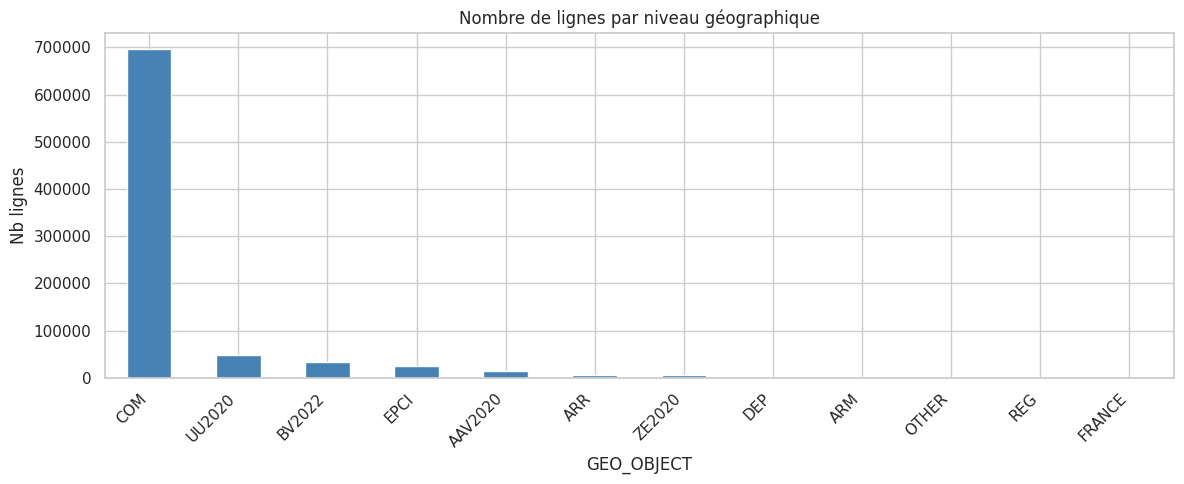

GEO_OBJECT
COM        696080
UU2020      48800
BV2022      33900
EPCI        24800
AAV2020     13840
ARR          6560
ZE2020       5940
DEP          1960
ARM           900
OTHER         300
REG           300
FRANCE         20
Name: count, dtype: int64


In [ ]:
geo = df['GEO_OBJECT'].value_counts()
ax = geo.plot(kind='bar', color='steelblue')
ax.set_title('Nombre de lignes par niveau géographique')
ax.set_ylabel('Nb lignes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(geo)

## 4. Les indicateurs FILOSOFI disponibles

In [ ]:
LABELS = {
    'MED_SL': 'Médiane niveau de vie (€)',
    'D1_SL': '1er décile niveau de vie (€)',
    'D9_SL': '9e décile niveau de vie (€)',
    'IR_D9_D1_SL': 'Rapport interdécile D9/D1',
    'PR_MD60': 'Taux de pauvreté à 60% (%)',
    'S_RET_PEN_DI': 'Part retraites/pensions (%)',
    'S_DIR_TAX_DI': 'Part impôts directs (%)',
    'S_SOC_BEN_DI': 'Part prestations sociales (%)',
    'S_SOC_BEN_DI_MIN_SOC': 'Part minima sociaux (%)',
    'S_SOC_BEN_DI_FAM_BEN': 'Part prestations familiales (%)',
    'S_SOC_BEN_DI_HOU_BEN': 'Part aides au logement (%)',
    'S_EI_DI': 'Part revenus d\'activité (%)',
    'NUM_HH': 'Nombre de ménages fiscaux',
    'NUM_PER': 'Nombre de personnes',
}
mesures = pd.DataFrame({'code': df['FILOSOFI_MEASURE'].unique()})
mesures['libellé'] = mesures['code'].map(LABELS).fillna('(autre indicateur FILOSOFI)')
from IPython.display import display
display(mesures)

,code,libellé
0,S_SOC_BEN_DI,Part prestations sociales (%)
1,S_SOC_BEN_DI_MIN_SOC,Part minima sociaux (%)
2,S_SOC_BEN_DI_FAM_BEN,Part prestations familiales (%)
3,NUM_PER,Nombre de personnes
4,S_EI_DI,Part revenus d'activité (%)
5,S_DIR_TAX_DI,Part impôts directs (%)
6,S_EI_DI_UNE,(autre indicateur FILOSOFI)
7,S_EI_DI_N_SAL,(autre indicateur FILOSOFI)
8,NUM_CU,(autre indicateur FILOSOFI)
9,PR_MD60,Taux de pauvreté à 60% (%)


## 5. Focus Paris : extraction au niveau arrondissement (ARM)
Les 20 arrondissements de Paris ont le code `751XX` au niveau `ARM`. On bascule du format long au format large (1 ligne = 1 arrondissement).

In [ ]:
paris = df[(df['GEO_OBJECT'] == 'ARM') & (df['GEO'].astype(str).str.startswith('751'))].copy()
print(f'Lignes Paris (ARM) : {len(paris)}')
print(f'Arrondissements    : {paris["GEO"].nunique()}')

piv = paris.pivot_table(index='GEO', columns='FILOSOFI_MEASURE', values='OBS_VALUE', aggfunc='first')
piv['arrondissement'] = piv.index.astype(str).str[-2:].astype(int)
piv = piv.sort_values('arrondissement')
print(f'Tableau Paris : {piv.shape}')
display(piv[['arrondissement', 'MED_SL', 'PR_MD60', 'IR_D9_D1_SL']].rename(columns=LABELS))

Lignes Paris (ARM) : 400
Arrondissements    : 20
Tableau Paris : (20, 21)


FILOSOFI_MEASURE,arrondissement,Médiane niveau de vie (€),Taux de pauvreté à 60% (%),Rapport interdécile D9/D1
GEO,,,,
75101,1,35030.0,12.0,7.5
75102,2,34050.0,14.0,7.3
75103,3,34800.0,13.0,7.4
75104,4,33040.0,14.0,7.4
75105,5,35960.0,11.0,6.5
75106,6,41750.0,11.0,9.5
75107,7,45380.0,9.0,10.2
75108,8,44100.0,10.0,9.6
75109,9,37220.0,11.0,6.7


## 6. Revenu médian par arrondissement

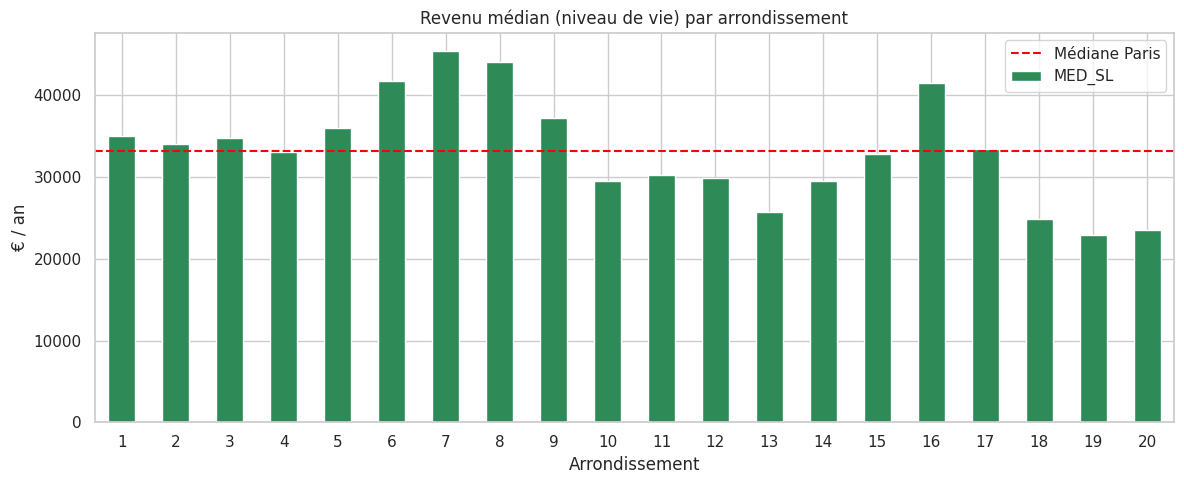

arrondissement
7     45380
8     44100
6     41750
16    41550
9     37220
5     35960
1     35030
3     34800
2     34050
17    33390
4     33040
15    32780
11    30210
12    29940
10    29470
14    29460
13    25670
18    24910
20    23570
19    22870
Name: MED_SL, dtype: int64


In [ ]:
s = piv.set_index('arrondissement')['MED_SL'].dropna()
ax = s.plot(kind='bar', color='seagreen')
ax.set_title('Revenu médian (niveau de vie) par arrondissement')
ax.set_xlabel('Arrondissement'); ax.set_ylabel('€ / an')
ax.axhline(s.median(), color='red', linestyle='--', label='Médiane Paris')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(s.sort_values(ascending=False).round(0).astype(int))

## 7. Taux de pauvreté par arrondissement

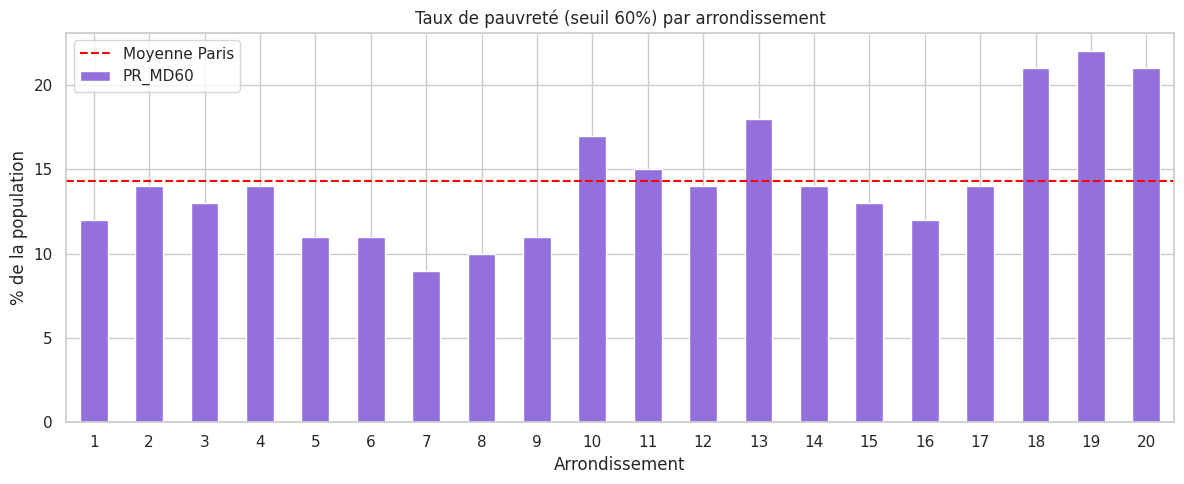

arrondissement
19    22.0
18    21.0
20    21.0
13    18.0
10    17.0
11    15.0
4     14.0
2     14.0
17    14.0
14    14.0
12    14.0
3     13.0
15    13.0
1     12.0
16    12.0
5     11.0
9     11.0
6     11.0
8     10.0
7      9.0
Name: PR_MD60, dtype: float64


In [ ]:
p = piv.set_index('arrondissement')['PR_MD60'].dropna()
ax = p.plot(kind='bar', color='mediumpurple')
ax.set_title('Taux de pauvreté (seuil 60%) par arrondissement')
ax.set_xlabel('Arrondissement'); ax.set_ylabel('% de la population')
ax.axhline(p.mean(), color='red', linestyle='--', label='Moyenne Paris')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(p.sort_values(ascending=False))

## 8. Inégalités : rapport interdécile (D9/D1)
Plus le rapport est élevé, plus l'écart entre les 10% les plus riches et les 10% les plus pauvres est grand au sein de l'arrondissement.

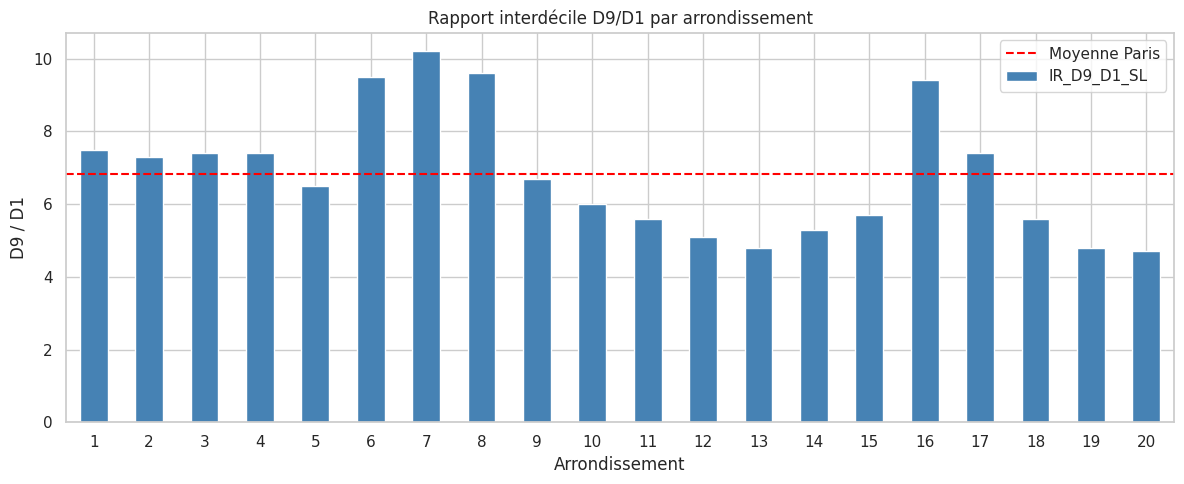

arrondissement
7     10.2
8      9.6
6      9.5
16     9.4
1      7.5
17     7.4
3      7.4
4      7.4
2      7.3
9      6.7
5      6.5
10     6.0
15     5.7
11     5.6
18     5.6
14     5.3
12     5.1
13     4.8
19     4.8
20     4.7
Name: IR_D9_D1_SL, dtype: float64


In [ ]:
g = piv.set_index('arrondissement')['IR_D9_D1_SL'].dropna()
ax = g.plot(kind='bar', color='steelblue')
ax.set_title('Rapport interdécile D9/D1 par arrondissement')
ax.set_xlabel('Arrondissement'); ax.set_ylabel('D9 / D1')
ax.axhline(g.mean(), color='red', linestyle='--', label='Moyenne Paris')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(g.sort_values(ascending=False))

## 9. Relation revenu médian / taux de pauvreté

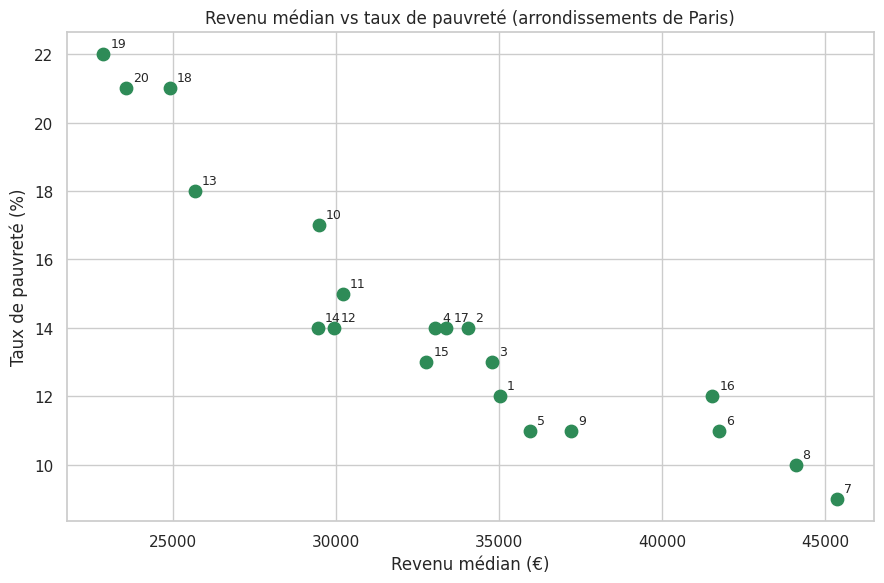

In [ ]:
comp = piv.set_index('arrondissement')[['MED_SL', 'PR_MD60']].dropna()
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(comp['MED_SL'], comp['PR_MD60'], color='seagreen', s=80)
for arr, row in comp.iterrows():
    ax.annotate(str(arr), (row['MED_SL'], row['PR_MD60']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('Revenu médian (€)'); ax.set_ylabel('Taux de pauvreté (%)')
ax.set_title('Revenu médian vs taux de pauvreté (arrondissements de Paris)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
plt.tight_layout()
plt.show()

## 10. Synthèse

In [ ]:
med = piv.set_index('arrondissement')['MED_SL'].dropna()
pov = piv.set_index('arrondissement')['PR_MD60'].dropna()
print('=== SYNTHÈSE EDA FILOSOFI PARIS ===')
print(f'Lignes totales (France)    : {len(df):,}')
print(f'Indicateurs FILOSOFI       : {df["FILOSOFI_MEASURE"].nunique()}')
print(f'Millésime                  : {df["TIME_PERIOD"].iloc[0]}')
print(f'Arrondissements Paris      : {piv["arrondissement"].nunique()} (75101-75120)')
print(f'\nRevenu médian Paris        : {med.median():.0f} €')
print(f'Arrondissement + aisé      : {med.idxmax()}e ({med.max():.0f} €)')
print(f'Arrondissement - aisé      : {med.idxmin()}e ({med.min():.0f} €)')
print(f'\nTaux pauvreté moyen Paris   : {pov.mean():.1f}%')
print(f'Pauvreté max               : {pov.idxmax()}e ({pov.max():.0f}%)')
print(f'Pauvreté min               : {pov.idxmin()}e ({pov.min():.0f}%)')
print(f'\nPLAN SILVER :')
print('  1. Filtrer GEO_OBJECT == ARM et GEO commençant par 751')
print('  2. Pivot long -> large (1 ligne = 1 arrondissement)')
print('  3. Conserver MED_SL, PR_MD60, IR_D9_D1_SL (+ autres au besoin)')
print('  4. Granularité ARRONDISSEMENT uniquement (FILOSOFI ne descend pas au quartier)')

=== SYNTHÈSE EDA FILOSOFI PARIS ===
Lignes totales (France)    : 833,400
Indicateurs FILOSOFI       : 20
Millésime                  : 2021
Arrondissements Paris      : 20 (75101-75120)

Revenu médian Paris        : 33215 €
Arrondissement + aisé      : 7e (45380 €)
Arrondissement - aisé      : 19e (22870 €)

Taux pauvreté moyen Paris   : 14.3%
Pauvreté max               : 19e (22%)
Pauvreté min               : 7e (9%)

PLAN SILVER :
  1. Filtrer GEO_OBJECT == ARM et GEO commençant par 751
  2. Pivot long -> large (1 ligne = 1 arrondissement)
  3. Conserver MED_SL, PR_MD60, IR_D9_D1_SL (+ autres au besoin)
  4. Granularité ARRONDISSEMENT uniquement (FILOSOFI ne descend pas au quartier)
